In [1]:
# ============================================================
# CELL 1: SETUP
# ============================================================

import os, re, cv2, copy, time, random, gc, math, hashlib, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from collections import Counter, defaultdict
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED   = 42

USE_AMP   = torch.cuda.is_available()
AMP_DTYPE = torch.float16 if USE_AMP else torch.float32

def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = True

seed_everything(SEED)
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

Device: cuda | AMP: True


In [2]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================

class CFG:
    data_root     = "/teamspace/studios/this_studio/EndoscopicBladderTissue"
    aug_root      = "/teamspace/studios/this_studio/Augmented Data"
    aug_manifest  = "/teamspace/studios/this_studio/Augmented Data/augmented_only_manifest.csv"

    cache_dir      = "feature_cache"
    cache_version  = "v2"

    class_names   = ['HGC', 'LGC', 'Normal']
    num_classes   = 3

    # Preprocessing
    image_resize  = 512
    clahe_clip    = 1.5
    clahe_grid    = (16, 16)

    # Multi-scale patches — more generous to capture HGC features
    patch_scales          = [96, 128, 192]
    patch_output_size     = 224
    patch_stride_frac     = 0.5
    min_tissue            = 0.40
    max_bright            = 245
    min_bright            = 15
    min_sat               = 10
    min_focus             = 8.0
    top_quality_frac      = 0.85
    max_patches_per_image = 60

    # Feature extraction
    feat_batch    = 64
    feat_dim      = 1024  # updated after backbone loading

    # CLAM architecture
    mil_hidden      = 512
    mil_dropout     = 0.25
    clam_k_sample   = 10
    feat_noise_std  = 0.03
    feat_drop_p     = 0.1
    inst_loss_w     = 0.3
    bag_loss_w      = 1.0
    label_smooth    = 0.05
    n_att_heads     = 4
    hier_loss_w     = 0.15

    # Focal loss
    focal_gamma       = 2.0
    hgc_weight_boost  = 1.5

    # Feature MixUp
    mixup_alpha     = 0.3
    mixup_prob      = 0.3

    # Training
    epochs           = 85
    patience         = 18
    lr               = 8e-5
    wd               = 5e-5
    grad_clip        = 1.0
    max_patches_train = 280
    max_patches_test  = 450
    warmup_epochs    = 5

    # Ensemble + TTA
    n_ensemble    = 5
    use_tta       = True
    tta_rounds    = 5
    ensemble_dropouts = [0.15, 0.20, 0.25, 0.30, 0.35]

    class_weights = None

IMNET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(DEVICE)
IMNET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(DEVICE)

LABEL_MAP = {'HGC': 'HGC', 'LGC': 'LGC', 'NST': 'Normal', 'NTL': 'Normal'}

# Binary grouping: cancer (HGC=0, LGC=1) vs normal (2)
CANCER_CLASSES = {0, 1}
NORMAL_CLASSES = {2}

os.makedirs(CFG.cache_dir, exist_ok=True)
print("✓ Config loaded (v2 — HGC-focused improvements)")

✓ Config loaded (v2 — HGC-focused improvements)


In [3]:
# ============================================================
# CELL 3: LOAD ORIGINAL DATASET
# ============================================================

print("\n" + "="*60)
print("LOADING ORIGINAL DATASET")
print("="*60)

records = []
pattern = re.compile(r'pt[_]?0*(\d+)')

for label in os.listdir(CFG.data_root):
    class_path = os.path.join(CFG.data_root, label)
    if not os.path.isdir(class_path):
        continue
    if label not in LABEL_MAP:
        print(f"  ⚠ Skipping unknown folder: {label}")
        continue
    for img_name in os.listdir(class_path):
        match = pattern.search(img_name)
        if match:
            records.append({
                "path":           os.path.join(class_path, img_name),
                "label":          LABEL_MAP[label],
                "original_label": label,
                "patient":        int(match.group(1)),
                "filename":       img_name,
                "is_augmented":   False,
                "aug_mode":       "none",
            })

df = pd.DataFrame(records)
class_to_idx = {c: i for i, c in enumerate(CFG.class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["target"] = df["label"].map(class_to_idx)

print(f"Total original images : {len(df)}")
print(f"Total patients        : {df.patient.nunique()}")
print(f"Classes               : {CFG.class_names}")

class_counts = df['label'].value_counts()
total = len(df)
print(f"\nClass distribution:")
for cls in CFG.class_names:
    n = class_counts.get(cls, 0)
    print(f"  {cls}: {n} ({100*n/total:.1f}%)")

PATIENTS   = sorted(df.patient.unique())
N_PATIENTS = len(PATIENTS)

print(f"\n{'Patient':<10} {'#Imgs':<8} {'Distribution'}")
print("-"*65)
for pid in PATIENTS:
    pdf    = df[df.patient == pid]
    counts = Counter(pdf.label.values)
    dist   = ", ".join(f"{k}:{v}" for k, v in sorted(counts.items()))
    print(f"  P{pid:<8} {len(pdf):<8} {dist}")

print(f"\n✓ {N_PATIENTS} patients, {len(df)} original images")


LOADING ORIGINAL DATASET
Total original images : 1607
Total patients        : 14
Classes               : ['HGC', 'LGC', 'Normal']

Class distribution:
  HGC: 426 (26.5%)
  LGC: 595 (37.0%)
  Normal: 586 (36.5%)

Patient    #Imgs    Distribution
-----------------------------------------------------------------
  P1        468      HGC:81, LGC:118, Normal:269
  P2        283      HGC:67, LGC:104, Normal:112
  P3        160      HGC:92, LGC:24, Normal:44
  P4        220      HGC:103, LGC:72, Normal:45
  P5        162      HGC:38, LGC:66, Normal:58
  P6        115      HGC:37, LGC:72, Normal:6
  P7        27       HGC:8, LGC:13, Normal:6
  P8        51       LGC:39, Normal:12
  P9        6        LGC:6
  P10       47       LGC:47
  P11       44       LGC:10, Normal:34
  P12       18       LGC:18
  P13       3        LGC:3
  P14       3        LGC:3

✓ 14 patients, 1607 original images


In [4]:
# ============================================================
# CELL 4: LOAD AUGMENTED DATASET
# ============================================================

print("\n" + "="*60)
print("LOADING AUGMENTED DATASET")
print("="*60)

aug_df = pd.read_csv(CFG.aug_manifest)

print(f"Manifest rows    : {len(aug_df)}")
print(f"Manifest columns : {aug_df.columns.tolist()}")
print(f"\nFirst row sample:")
print(aug_df.iloc[0].to_dict())

print("\nBuilding file index from disk...")
aug_file_index = {}
for root, dirs, files in os.walk(CFG.aug_root):
    for fname in files:
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            aug_file_index[fname] = os.path.join(root, fname)
print(f"Indexed {len(aug_file_index)} image files from disk")

FNAME_COL = None
for candidate in ['HLY', 'filename', 'aug_filename', 'file']:
    if candidate in aug_df.columns:
        FNAME_COL = candidate
        break
if FNAME_COL is None:
    for col in aug_df.columns:
        sample = str(aug_df[col].iloc[0])
        if sample.strip().endswith(('.png', '.jpg', '.jpeg')):
            FNAME_COL = col
            break
if FNAME_COL is None:
    raise ValueError(f"Could not find filename column. Columns: {aug_df.columns.tolist()}")

print(f"Using filename column : '{FNAME_COL}'")

def resolve_aug_path(fname):
    fname = str(fname).strip()
    if fname in aug_file_index:
        return aug_file_index[fname]
    basename = os.path.basename(fname)
    if basename in aug_file_index:
        return aug_file_index[basename]
    return None

aug_df['path'] = aug_df[FNAME_COL].apply(resolve_aug_path)
missing = aug_df['path'].isna().sum()
aug_df  = aug_df[aug_df['path'].notna()].reset_index(drop=True)
print(f"\nResolved : {len(aug_df)} | Missing : {missing}")

aug_df['label'] = aug_df['tissue type'].map(LABEL_MAP)
unmapped = aug_df['label'].isna().sum()
if unmapped:
    print(f"⚠ Dropping {unmapped} rows with unmapped tissue type")
    aug_df = aug_df[aug_df['label'].notna()].copy()

aug_df['target']       = aug_df['label'].map(class_to_idx)
aug_df['is_augmented'] = True

if 'patient_id' in aug_df.columns:
    aug_df = aug_df.rename(columns={'patient_id': 'patient'})
if 'patient' not in aug_df.columns:
    raise ValueError(f"No patient column. Columns: {aug_df.columns.tolist()}")
aug_df['patient'] = aug_df['patient'].astype(int)

print("\nVerifying sample files:")
ok, fail = 0, 0
for _, row in aug_df.head(5).iterrows():
    img = cv2.imread(row['path'])
    if img is not None: ok += 1
    else: fail += 1
if fail == 0:
    print(f"  {ok}/5 readable ✓")
else:
    print(f"  {ok}/5 ok, {fail} failed ✗")

print(f"\nAugmented class distribution:")
for cls in CFG.class_names:
    n = (aug_df['label'] == cls).sum()
    print(f"  {cls}: {n}")

print(f"\n✓ {len(aug_df)} augmented images ready")


LOADING AUGMENTED DATASET
Manifest rows    : 1676
Manifest columns : ['HLY', 'tissue type', 'imaging type', 'patient_id', 'is_augmented', 'aug_mode', 'source_filename', 'source_domain', 'source_abs_path', 'aug_abs_path', 'full_path', 'sub_dataset', 'abs_path']

First row sample:
{'HLY': 'case_002_pt_003_frame_0009_WLI2NBI.png', 'tissue type': 'HGC', 'imaging type': 'NBI', 'patient_id': 3, 'is_augmented': True, 'aug_mode': 'WLI2NBI', 'source_filename': 'case_002_pt_003_frame_0009.png', 'source_domain': 'WLI', 'source_abs_path': '/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue/HGC/case_002_pt_003_frame_0009.png', 'aug_abs_path': '/kaggle/working/augmented_data/WLI2NBI/HGC/case_002_pt_003_frame_0009_WLI2NBI.png', 'full_path': 'WLI2NBI/HGC/case_002_pt_003_frame_0009_WLI2NBI.png', 'sub_dataset': 'train', 'abs_path': '/kaggle/input/datasets/aryashah2k/endoscopic-bladder-tissue-classification-dataset/EndoscopicBladderTissue/HGC/case_

In [5]:
# ============================================================
# CELL 5: CLASS WEIGHTS (with HGC boost)
# ============================================================

weights = []
print(f"\nClass weights (HGC boosted ×{CFG.hgc_weight_boost}):")
for cls in CFG.class_names:
    count = class_counts.get(cls, 0)
    w     = total / (CFG.num_classes * max(count, 1))
    if cls == 'HGC':
        w *= CFG.hgc_weight_boost
    weights.append(w)
    print(f"  {cls}: {count} images → weight={w:.3f}")

CFG.class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
print(f"Class weights tensor: {CFG.class_weights}")


Class weights (HGC boosted ×1.5):
  HGC: 426 images → weight=1.886
  LGC: 595 images → weight=0.900
  Normal: 586 images → weight=0.914
Class weights tensor: tensor([1.8862, 0.9003, 0.9141], device='cuda:0')


In [6]:
# ============================================================
# CELL 6: LAB NORMALIZER + CLAHE
# ============================================================

class LabNormalizer:
    def __init__(self):
        self.ref = None

    def fit(self, images_bgr):
        stats = {'L': [], 'a': [], 'b': []}
        for img in images_bgr:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
            for i, ch in enumerate(['L', 'a', 'b']):
                stats[ch].append({
                    'm': lab[:, :, i].mean(),
                    's': lab[:, :, i].std() + 1e-6
                })
        self.ref = {
            ch: {
                'm': np.median([s['m'] for s in stats[ch]]),
                's': np.median([s['s'] for s in stats[ch]])
            }
            for ch in ['L', 'a', 'b']
        }
        return self

    def transform(self, img_bgr):
        lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
        for i, ch in enumerate(['L', 'a', 'b']):
            c  = lab[:, :, i]
            sm, ss = c.mean(), c.std() + 1e-6
            lab[:, :, i] = np.clip(
                (c - sm) * (self.ref[ch]['s'] / ss) + self.ref[ch]['m'],
                0, 255
            )
        lab = lab.astype(np.uint8)
        clahe = cv2.createCLAHE(
            clipLimit=CFG.clahe_clip, tileGridSize=CFG.clahe_grid
        )
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


def load_image(path, norm=None):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    h, w = img.shape[:2]
    s    = CFG.image_resize / max(h, w)
    if s != 1:
        img = cv2.resize(img, (int(w * s), int(h * s)),
                         interpolation=cv2.INTER_AREA)
    if norm:
        img = norm.transform(img)
    return img


def fit_normalizer_excluding(exclude_pid=None):
    samples = []
    for pid in PATIENTS:
        if pid == exclude_pid:
            continue
        for fp in df[df.patient == pid].path.values[:12]:
            try:
                img = cv2.imread(fp)
                if img is not None:
                    h, w = img.shape[:2]
                    s    = CFG.image_resize / max(h, w)
                    if s != 1:
                        img = cv2.resize(img, (int(w * s), int(h * s)))
                    samples.append(img)
            except:
                pass
    return LabNormalizer().fit(samples)


global_normalizer = fit_normalizer_excluding(exclude_pid=None)
print("✓ Global normalizer fitted")

✓ Global normalizer fitted


In [7]:
# ============================================================
# CELL 7: MULTI-SCALE PATCH EXTRACTION
# ============================================================

def compute_quality(patch_bgr):
    hsv = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2HSV)
    v   = hsv[:, :, 2].astype(np.float32)
    s   = hsv[:, :, 1].astype(np.float32)

    mask        = (v < CFG.max_bright) & (v > CFG.min_bright) & (s > CFG.min_sat)
    tissue_frac = mask.sum() / mask.size
    if tissue_frac < CFG.min_tissue:
        return -1.0

    gray  = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2GRAY)
    focus = cv2.Laplacian(gray, cv2.CV_64F).var()
    if focus < CFG.min_focus:
        return -1.0

    focus_norm   = min(focus / 100.0, 1.0)
    sat_std      = s[mask].std() / 50.0 if mask.sum() > 10 else 0
    sat_norm     = min(sat_std, 1.0)
    edges        = cv2.Canny(gray, 50, 150)
    edge_density = min(edges.sum() / (255.0 * edges.size) * 10, 1.0)

    return 0.3*tissue_frac + 0.3*focus_norm + 0.2*sat_norm + 0.2*edge_density


def extract_multiscale_patches(image_bgr, max_patches=None):
    if max_patches is None:
        max_patches = CFG.max_patches_per_image

    H, W       = image_bgr.shape[:2]
    candidates = []
    cap        = max_patches * 3

    for scale in CFG.patch_scales:
        if scale > min(H, W):
            continue
        stride = max(1, int(scale * CFG.patch_stride_frac))
        for y in range(0, H - scale + 1, stride):
            for x in range(0, W - scale + 1, stride):
                if len(candidates) >= cap:
                    break
                crop = image_bgr[y:y+scale, x:x+scale]
                q    = compute_quality(crop)
                if q > 0:
                    resized = cv2.resize(
                        crop,
                        (CFG.patch_output_size, CFG.patch_output_size),
                        interpolation=cv2.INTER_AREA
                    )
                    candidates.append((resized, q, scale))
            if len(candidates) >= cap:
                break

    if not candidates:
        return [], [], []

    candidates.sort(key=lambda x: x[1], reverse=True)
    n_keep     = max(1, int(len(candidates) * CFG.top_quality_frac))
    candidates = candidates[:n_keep][:max_patches]

    return ([c[0] for c in candidates],
            [c[1] for c in candidates],
            [c[2] for c in candidates])


test_img = load_image(df.iloc[0].path, global_normalizer)
tp, _, tsc = extract_multiscale_patches(test_img)
print(f"✓ Patch test: {test_img.shape} → {len(tp)} patches")
del tp, tsc, test_img; gc.collect()

✓ Patch test: (512, 512, 3) → 60 patches


26

In [8]:
# ============================================================
# CELL 8: DUAL BACKBONE — DINOv2 + DenseNet121
# ============================================================

def load_dinov2():
    print("  Loading DINOv2...")
    for model_name, dim in [
        ('dinov2_vitb14', 768),
        ('dinov2_vits14', 384),
    ]:
        try:
            model = torch.hub.load('facebookresearch/dinov2', model_name)
            model.eval()
            for p in model.parameters():
                p.requires_grad = False
            print(f"  ✓ {model_name} — dim={dim}")
            return model.to(DEVICE), dim
        except Exception as e:
            print(f"  ⚠ {model_name} failed: {e}")
    try:
        model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16')
        model.eval()
        for p in model.parameters():
            p.requires_grad = False
        print("  ✓ DINO ViT-S/16 fallback — dim=384")
        return model.to(DEVICE), 384
    except Exception as e:
        print(f"  ⚠ All DINO models failed: {e}")
        return None, 0


def load_densenet():
    model    = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    feat_dim = model.classifier.in_features
    model.classifier = nn.Identity()
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model.to(DEVICE), feat_dim


print("Loading backbones...")
dino_model,  dino_dim  = load_dinov2()
dense_model, dense_dim = load_densenet()
print(f"  ✓ DenseNet121 — dim={dense_dim}")

CFG.feat_dim = (dino_dim if dino_model else 0) + dense_dim

backbone_parts = []
if dino_model is not None:
    backbone_parts.append(f"DINOv2({dino_dim})")
backbone_parts.append(f"DenseNet121({dense_dim})")
backbone_desc = " + ".join(backbone_parts)

print(f"\n✓ Feature dim: {CFG.feat_dim} | {backbone_desc}")

Loading backbones...
  Loading DINOv2...


Using cache found in /home/zeus/.cache/torch/hub/facebookresearch_dinov2_main
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/zeus/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  ✓ dinov2_vitb14 — dim=768
  ✓ DenseNet121 — dim=1024

✓ Feature dim: 1792 | DINOv2(768) + DenseNet121(1024)


In [9]:
# ============================================================
# CELL 9: FEATURE EXTRACTION (AMP + FP16 + cache)
# ============================================================

def bgr_to_tensor(patch_bgr):
    rgb = cv2.cvtColor(patch_bgr, cv2.COLOR_BGR2RGB)
    return torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0


def _get_cache_key(path):
    key_str = f"{path}|{CFG.image_resize}|{CFG.patch_scales}|{CFG.max_patches_per_image}|{CFG.cache_version}"
    return hashlib.md5(key_str.encode()).hexdigest()


@torch.no_grad()
def extract_dual_features(tensor_list):
    all_feats = []
    for i in range(0, len(tensor_list), CFG.feat_batch):
        batch      = torch.stack(tensor_list[i:i+CFG.feat_batch]).to(DEVICE)
        batch_norm = (batch - IMNET_MEAN) / IMNET_STD
        parts      = []

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            if dino_model is not None:
                dino_out = dino_model(batch_norm)
                if isinstance(dino_out, dict):
                    dino_feats = dino_out.get('x_norm_clstoken',
                                 next(iter(dino_out.values())))
                else:
                    dino_feats = dino_out
                if dino_feats.dim() > 2:
                    dino_feats = dino_feats[:, 0, :]
                parts.append(dino_feats.float().cpu())
            parts.append(dense_model(batch_norm).float().cpu())

        all_feats.append(torch.cat(parts, dim=1))

    result = torch.cat(all_feats, 0)
    return result.half()


def extract_features_for_rows(row_df, desc="Extracting", norm=None,
                              use_cache=True):
    results    = []
    skipped    = 0
    cache_hits = 0

    for _, row in tqdm(row_df.iterrows(), total=len(row_df), desc=desc):
        cache_path = None
        if use_cache:
            cache_key  = _get_cache_key(row.path)
            cache_path = os.path.join(CFG.cache_dir, f"{cache_key}.pt")
            if os.path.exists(cache_path):
                try:
                    cached = torch.load(cache_path, map_location='cpu')
                    results.append({
                        'features'     : cached['features'],
                        'label'        : int(row.target),
                        'label_name'   : row.label,
                        'patient'      : int(row.patient),
                        'path'         : row.path,
                        'is_augmented' : bool(row.is_augmented),
                        'aug_mode'     : str(row.get('aug_mode', 'none')),
                        'n_patches'    : cached['features'].shape[0],
                    })
                    cache_hits += 1
                    continue
                except:
                    pass

        try:
            img = load_image(row.path, norm)
        except Exception:
            skipped += 1
            continue

        patches, _, _ = extract_multiscale_patches(img)
        if not patches:
            skipped += 1
            continue

        tensors = [bgr_to_tensor(p) for p in patches]
        if len(tensors) > CFG.max_patches_per_image:
            idx     = random.sample(range(len(tensors)), CFG.max_patches_per_image)
            tensors = [tensors[i] for i in sorted(idx)]

        feats = extract_dual_features(tensors)

        if cache_path:
            torch.save({'features': feats}, cache_path)

        results.append({
            'features'     : feats,
            'label'        : int(row.target),
            'label_name'   : row.label,
            'patient'      : int(row.patient),
            'path'         : row.path,
            'is_augmented' : bool(row.is_augmented),
            'aug_mode'     : str(row.get('aug_mode', 'none')),
            'n_patches'    : feats.shape[0],
        })

    if skipped:
        print(f"  ⚠ Skipped {skipped} images")
    if cache_hits:
        print(f"  ⚡ Cache hits: {cache_hits}/{len(row_df)}")
    return results


# ── Extract original images ──────────────────────────────────
print("\n" + "="*60)
print("EXTRACTING FEATURES — ORIGINAL IMAGES")
print("="*60)
t0 = time.time()
orig_image_data = extract_features_for_rows(
    df, desc="Original", norm=global_normalizer
)
print(f"✓ {len(orig_image_data)} original images | {(time.time()-t0)/60:.1f} min")

# ── Extract augmented images ─────────────────────────────────
print("\n" + "="*60)
print("EXTRACTING FEATURES — AUGMENTED IMAGES")
print("="*60)
t0 = time.time()
aug_image_data = extract_features_for_rows(
    aug_df, desc="Augmented", norm=global_normalizer
)
print(f"✓ {len(aug_image_data)} augmented images | {(time.time()-t0)/60:.1f} min")

# ── Memory summary ───────────────────────────────────────────
def mem_gb(data_list):
    return sum(
        d['features'].element_size() * d['features'].nelement()
        for d in data_list
    ) / 1e9

print(f"\nMemory — original  : {mem_gb(orig_image_data):.2f} GB")
print(f"Memory — augmented : {mem_gb(aug_image_data):.2f} GB")
print(f"Memory — total     : {mem_gb(orig_image_data + aug_image_data):.2f} GB")

# ── Free backbones ───────────────────────────────────────────
del dino_model, dense_model
torch.cuda.empty_cache(); gc.collect()
print("\n✓ Backbones freed from GPU")


EXTRACTING FEATURES — ORIGINAL IMAGES


Original:   0%|          | 0/1607 [00:00<?, ?it/s]/tmp/ipykernel_4753/1750887961.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Original: 100%|██████████| 1607/1607 [12:02<00:00,  2.22it/s]


✓ 1607 original images | 12.0 min

EXTRACTING FEATURES — AUGMENTED IMAGES


Augmented:   0%|          | 0/1588 [00:00<?, ?it/s]/tmp/ipykernel_4753/1750887961.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
Augmented: 100%|██████████| 1588/1588 [11:55<00:00,  2.22it/s]


✓ 1588 augmented images | 11.9 min

Memory — original  : 0.35 GB
Memory — augmented : 0.34 GB
Memory — total     : 0.69 GB

✓ Backbones freed from GPU


In [10]:
# ============================================================
# CELL 10: FOCAL LOSS + HIERARCHICAL LOSS
# ============================================================

class FocalLoss(nn.Module):
    """Focal loss — down-weights easy examples, focuses on hard ones (HGC)."""
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma           = gamma
        self.weight          = weight
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


def hierarchical_loss(logits, label):
    """
    Binary cancer-vs-normal loss.
    Forces the model to first get the coarse decision right,
    which helps disambiguate HGC from Normal.
    """
    # logits shape: (num_classes,) — already 1D
    cancer_score = logits[0] + logits[1]   # HGC + LGC
    normal_score = logits[2]               # Normal
    binary_logit = torch.stack([cancer_score, normal_score]).unsqueeze(0)

    if label.item() in CANCER_CLASSES:
        binary_target = torch.tensor([0], dtype=torch.long, device=label.device)
    else:
        binary_target = torch.tensor([1], dtype=torch.long, device=label.device)

    return F.cross_entropy(binary_logit, binary_target)


print("✓ Focal loss + hierarchical loss ready")

✓ Focal loss + hierarchical loss ready


In [11]:
# ============================================================
# CELL 11: IMPROVED CLAM MODEL (multi-head + temperature)
# ============================================================

class MultiHeadGatedAttention(nn.Module):
    """Multi-head gated attention — captures diverse morphological patterns."""
    def __init__(self, hidden, n_heads=4):
        super().__init__()
        self.n_heads  = n_heads
        self.head_dim = hidden // 2 // n_heads
        assert self.head_dim > 0, f"head_dim=0 with hidden={hidden}, n_heads={n_heads}"

        self.att_nets  = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, self.head_dim), nn.Tanh())
            for _ in range(n_heads)
        ])
        self.gate_nets = nn.ModuleList([
            nn.Sequential(nn.Linear(hidden, self.head_dim), nn.Sigmoid())
            for _ in range(n_heads)
        ])
        self.combine = nn.Linear(self.head_dim * n_heads, hidden // 2)

    def forward(self, h):
        head_outs = []
        for att, gate in zip(self.att_nets, self.gate_nets):
            head_outs.append(att(h) * gate(h))
        multi = torch.cat(head_outs, dim=-1)  # (N, head_dim * n_heads)
        return self.combine(multi)             # (N, hidden//2)


class CLAM(nn.Module):
    def __init__(self, feat_dim=CFG.feat_dim, hidden=CFG.mil_hidden,
                 n_classes=CFG.num_classes, dropout=CFG.mil_dropout,
                 k_sample=CFG.clam_k_sample, n_heads=CFG.n_att_heads):
        super().__init__()
        self.n_classes  = n_classes
        self.k_sample   = k_sample
        self.feat_noise = CFG.feat_noise_std
        self.feat_drop  = nn.Dropout(CFG.feat_drop_p)

        self.fc = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # Multi-head gated attention
        self.mh_attention = MultiHeadGatedAttention(hidden, n_heads)

        # Learnable temperature per class
        self.att_temp = nn.Parameter(torch.ones(n_classes))

        self.att_branches = nn.ModuleList([
            nn.Linear(hidden // 2, 1) for _ in range(n_classes)
        ])

        # Stronger instance classifiers
        self.inst_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, 128),
                nn.GELU(),
                nn.Dropout(0.1),
                nn.Linear(128, 2)
            )
            for _ in range(n_classes)
        ])

        self.bag_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden, hidden // 4),
                nn.GELU(),
                nn.Linear(hidden // 4, 1)
            )
            for _ in range(n_classes)
        ])

    def _inst_loss(self, scores, h, classifier, k):
        N = scores.shape[0]
        k = min(k, N // 2, 8)
        if k < 1:
            return torch.tensor(0.0, device=h.device)
        top_idx = torch.topk(scores, k).indices
        bot_idx = torch.topk(scores, k, largest=False).indices
        feats   = torch.cat([h[top_idx], h[bot_idx]], dim=0)
        labels  = torch.cat([
            torch.ones(k, dtype=torch.long),
            torch.zeros(k, dtype=torch.long)
        ]).to(h.device)
        return F.cross_entropy(classifier(feats), labels)

    def forward(self, x, label=None):
        x = x.float()

        if self.training:
            x = x + torch.randn_like(x) * self.feat_noise
            x = self.feat_drop(x)

        h   = self.fc(x)
        att = self.mh_attention(h)

        logits     = []
        total_inst = torch.tensor(0.0, device=x.device)

        for c in range(self.n_classes):
            a_scores  = self.att_branches[c](att).squeeze(-1)
            a_scores  = a_scores / (self.att_temp[c].abs() + 0.1)
            a_weights = F.softmax(a_scores, dim=0)
            bag       = torch.sum(a_weights.unsqueeze(-1) * h, dim=0)
            logits.append(self.bag_classifiers[c](bag))

            if self.training and label is not None and label.item() == c:
                total_inst += self._inst_loss(
                    a_scores.detach(), h,
                    self.inst_classifiers[c], self.k_sample
                )

        return {'logits': torch.cat(logits), 'inst_loss': total_inst}


# Smoke test
_m = CLAM().to(DEVICE)
_x = torch.randn(30, CFG.feat_dim).to(DEVICE)
_l = torch.tensor(0, dtype=torch.long).to(DEVICE)
_m.train()
_o = _m(_x, label=_l)
print(f"✓ CLAM: (30, {CFG.feat_dim}) → logits {_o['logits'].shape}")
print(f"  Params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}")
del _m, _x, _o; torch.cuda.empty_cache()

✓ CLAM: (30, 1792) → logits torch.Size([3])
  Params: 1,643,407


In [12]:
# ============================================================
# CELL 12: COMPUTE LOSS (focal + hierarchical + instance)
# ============================================================

def compute_loss(output, label, class_weights=None, focal_criterion=None):
    """Combined loss: focal bag + hierarchical + instance."""
    logits = output['logits'].unsqueeze(0)
    target = label.unsqueeze(0)

    # Primary: focal loss
    if focal_criterion is not None:
        bag_loss = focal_criterion(logits, target)
    else:
        bag_loss = F.cross_entropy(
            logits, target,
            weight=class_weights,
            label_smoothing=CFG.label_smooth
        )

    # Hierarchical: cancer vs normal
    hier_loss = hierarchical_loss(output['logits'], label)

    total = (CFG.bag_loss_w * bag_loss +
             CFG.hier_loss_w * hier_loss +
             CFG.inst_loss_w * output['inst_loss'])

    return total


print("✓ Combined loss function ready")

✓ Combined loss function ready


In [13]:
# ============================================================
# CELL 13: FEATURE MIXUP
# ============================================================

def feature_mixup(data_list, alpha=CFG.mixup_alpha):
    """
    Create synthetic training bags by mixing features of
    same-class images. Especially helps underrepresented HGC.
    """
    by_class = defaultdict(list)
    for d in data_list:
        by_class[d['label']].append(d)

    mixed = []
    for cls, items in by_class.items():
        if len(items) < 2:
            continue
        # More mixup for HGC (the weak class)
        n_mix = len(items) if cls == 0 else len(items) // 2
        for _ in range(n_mix):
            if random.random() > CFG.mixup_prob:
                continue
            i, j = random.sample(range(len(items)), 2)
            lam  = np.random.beta(alpha, alpha)

            f1 = items[i]['features']
            f2 = items[j]['features']

            # Match sizes
            min_n = min(f1.shape[0], f2.shape[0])
            idx1  = torch.randperm(f1.shape[0])[:min_n]
            idx2  = torch.randperm(f2.shape[0])[:min_n]

            mixed_feats = lam * f1[idx1] + (1 - lam) * f2[idx2]

            mixed.append({
                'features'     : mixed_feats,
                'label'        : cls,
                'label_name'   : items[i]['label_name'],
                'patient'      : items[i]['patient'],
                'path'         : 'mixup',
                'is_augmented' : True,
                'aug_mode'     : 'mixup',
                'n_patches'    : mixed_feats.shape[0],
            })

    return mixed


print("✓ Feature MixUp ready")

✓ Feature MixUp ready


In [14]:
# ============================================================
# CELL 14: TRAIN / PREDICT HELPERS
# ============================================================

def get_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs, last_epoch=-1):
    """Linear warmup then cosine annealing."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda, last_epoch=last_epoch)


def train_clam(model, train_images, val_images=None,
               epochs=CFG.epochs, class_weights=None,
               dropout_override=None, verbose=False):
    """Train with focal loss, warmup, mixup, AMP."""
    model.train()

    # Override dropout for ensemble diversity
    if dropout_override is not None:
        for module in model.modules():
            if isinstance(module, nn.Dropout):
                module.p = dropout_override

    focal_criterion = FocalLoss(
        gamma=CFG.focal_gamma,
        weight=class_weights,
        label_smoothing=CFG.label_smooth
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=CFG.lr, weight_decay=CFG.wd
    )
    scheduler = get_warmup_cosine_scheduler(
        optimizer, CFG.warmup_epochs, epochs
    )
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_val_loss  = float('inf')
    best_state     = None
    patience_count = 0

    # Generate mixup samples once per training run
    mixup_samples = feature_mixup(train_images)
    if mixup_samples:
        if verbose:
            print(f"    MixUp generated {len(mixup_samples)} synthetic bags")

    for epoch in range(epochs):
        model.train()
        # Each epoch: original train + fresh shuffle of mixup
        epoch_data = train_images.copy()
        if mixup_samples:
            epoch_data.extend(random.sample(
                mixup_samples, min(len(mixup_samples), len(train_images) // 3)
            ))
        random.shuffle(epoch_data)

        epoch_loss = 0.0
        for img_data in epoch_data:
            feats = img_data['features'].to(DEVICE)
            lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)

            if feats.shape[0] > CFG.max_patches_train:
                idx   = torch.randperm(feats.shape[0])[:CFG.max_patches_train]
                feats = feats[idx]

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                out  = model(feats, label=lbl)
                loss = compute_loss(out, lbl, class_weights, focal_criterion)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        scheduler.step()

        # Validation
        if val_images:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for img_data in val_images:
                    feats = img_data['features'].to(DEVICE)
                    lbl   = torch.tensor(img_data['label'], dtype=torch.long).to(DEVICE)
                    if feats.shape[0] > CFG.max_patches_test:
                        idx   = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
                        feats = feats[idx]
                    with torch.cuda.amp.autocast(enabled=USE_AMP):
                        out      = model(feats, label=lbl)
                        val_loss += compute_loss(out, lbl, class_weights, focal_criterion).item()

            avg_val = val_loss / max(len(val_images), 1)

            if avg_val < best_val_loss:
                best_val_loss  = avg_val
                best_state     = copy.deepcopy(model.state_dict())
                patience_count = 0
            else:
                patience_count += 1

            if patience_count >= CFG.patience:
                if verbose:
                    print(f"    Early stop at epoch {epoch+1}")
                break

            if verbose and (epoch + 1) % 20 == 0:
                print(f"    Epoch {epoch+1} | "
                      f"train={epoch_loss/len(epoch_data):.4f} "
                      f"val={avg_val:.4f} "
                      f"lr={optimizer.param_groups[0]['lr']:.2e}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


@torch.no_grad()
def predict_image(model, feats):
    model.eval()
    feats = feats.to(DEVICE)
    if feats.shape[0] > CFG.max_patches_test:
        idx   = torch.randperm(feats.shape[0])[:CFG.max_patches_test]
        feats = feats[idx]
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        out = model(feats)
    probs = F.softmax(out['logits'].float(), dim=0)
    return probs.argmax().item(), probs.max().item(), probs.cpu().numpy()


def predict_image_ensemble(models_list, feats, use_tta=False):
    """Geometric mean ensemble — better than arithmetic for probabilities."""
    all_probs = []
    for model in models_list:
        if use_tta and CFG.use_tta:
            tta_probs = []
            for _ in range(CFG.tta_rounds):
                _, _, p = predict_image(model, feats)
                tta_probs.append(p)
            all_probs.append(np.mean(tta_probs, axis=0))
        else:
            _, _, p = predict_image(model, feats)
            all_probs.append(p)

    # Geometric mean (log-space for numerical stability)
    log_probs = np.log(np.array(all_probs) + 1e-8)
    geo_mean  = np.exp(np.mean(log_probs, axis=0))
    geo_mean  = geo_mean / geo_mean.sum()  # renormalise

    return np.argmax(geo_mean), geo_mean.max(), geo_mean


print("✓ Train/predict helpers ready (focal + warmup + mixup + geo-ensemble)")

✓ Train/predict helpers ready (focal + warmup + mixup + geo-ensemble)


In [15]:
# ============================================================
# CELL 15: LOPO ENGINE
# ============================================================

def compute_fold_class_weights(train_images):
    counts  = Counter(d['label'] for d in train_images)
    total_n = sum(counts.values())
    weights = torch.zeros(CFG.num_classes)
    for c in range(CFG.num_classes):
        weights[c] = total_n / (CFG.num_classes * max(counts.get(c, 0), 1))
    # Boost HGC
    weights[class_to_idx['HGC']] *= CFG.hgc_weight_boost
    return weights.to(DEVICE)


def create_validation_split(train_images):
    orig_only = [d for d in train_images if not d['is_augmented']]
    aug_only  = [d for d in train_images if d['is_augmented']]

    patient_groups = defaultdict(list)
    for d in orig_only:
        patient_groups[d['patient']].append(d)

    patients = list(patient_groups.keys())
    if len(patients) < 3:
        return train_images, []

    n_val  = 2 if len(patients) >= 8 else 1
    p_sizes = sorted([(p, len(imgs)) for p, imgs in patient_groups.items()],
                     key=lambda x: x[1])
    mid     = len(p_sizes) // 2
    val_pids = [p_sizes[mid - i][0] for i in range(n_val)]

    val_imgs = []
    for p in val_pids:
        val_imgs.extend(patient_groups[p])

    tr_orig = [d for d in orig_only if d['patient'] not in val_pids]
    # Also remove augmented images from val patients
    tr_aug  = [d for d in aug_only if d['patient'] not in val_pids]
    tr_imgs = tr_orig + tr_aug

    return tr_imgs, val_imgs


def run_lopo_with_augmentation(orig_data, aug_data):
    tag = "WITH CSi-GAN AUG + FOCAL + HIER + MIXUP + MULTIHEAD"
    print(f"\n{'='*60}")
    print(f"  LOPO: {tag}")
    print(f"  {N_PATIENTS} folds × {CFG.n_ensemble} diverse seeds")
    print(f"{'='*60}\n")

    fold_results = []
    all_y_true   = []
    all_y_pred   = []
    all_y_probs  = []

    aug_by_patient = defaultdict(list)
    for d in aug_data:
        aug_by_patient[d['patient']].append(d)

    for fold_idx, test_pid in enumerate(PATIENTS):
        fold_start = time.time()
        print(f"\nFold {fold_idx+1}/{N_PATIENTS} — Test patient: P{test_pid}")

        test_images = [d for d in orig_data if d['patient'] == test_pid]
        if not test_images:
            print(f"  ⚠ No test images — skipping")
            continue

        orig_train = [d for d in orig_data  if d['patient'] != test_pid]
        aug_train  = [d for d in aug_data   if d['patient'] != test_pid]

        print(f"  Orig train : {len(orig_train)} | "
              f"Aug train : {len(aug_train)} | "
              f"Test : {len(test_images)}")

        combined_train = orig_train + aug_train
        tr_imgs, val_imgs = create_validation_split(combined_train)

        n_orig_tr = len([d for d in tr_imgs if not d['is_augmented']])
        n_aug_tr  = len([d for d in tr_imgs if d['is_augmented']])
        print(f"  Train: {len(tr_imgs)} ({n_orig_tr} orig + {n_aug_tr} aug) | "
              f"Val: {len(val_imgs)}")

        fold_weights = compute_fold_class_weights(tr_imgs)

        # ── Train diverse ensemble ───────────────────────────
        models_list = []
        for seed_off in range(CFG.n_ensemble):
            seed_everything(SEED + fold_idx * 100 + seed_off)

            # Each member gets different dropout for diversity
            drop_p = CFG.ensemble_dropouts[seed_off % len(CFG.ensemble_dropouts)]

            model = CLAM().to(DEVICE)
            model = train_clam(
                model, tr_imgs,
                val_images=val_imgs,
                epochs=CFG.epochs,
                class_weights=fold_weights,
                dropout_override=drop_p,
                verbose=(seed_off == 0)
            )
            models_list.append(model)

        # ── Predict ──────────────────────────────────────────
        fold_true = []
        fold_pred = []
        fold_conf = []

        for img_data in test_images:
            pred, conf, probs = predict_image_ensemble(
                models_list, img_data['features'], use_tta=True
            )
            fold_true.append(img_data['label'])
            fold_pred.append(pred)
            fold_conf.append(conf)
            all_y_probs.append(probs)

        for m in models_list:
            del m
        torch.cuda.empty_cache()

        fold_true = np.array(fold_true)
        fold_pred = np.array(fold_pred)
        fold_acc  = accuracy_score(fold_true, fold_pred)
        fold_bal  = balanced_accuracy_score(fold_true, fold_pred)
        fold_time = time.time() - fold_start

        print(f"  Accuracy : {fold_acc:.4f} "
              f"({(fold_true==fold_pred).sum()}/{len(fold_true)})")
        print(f"  Balanced : {fold_bal:.4f} | Time: {fold_time/60:.1f} min")

        fold_results.append({
            'patient':           test_pid,
            'n_test_images':     len(test_images),
            'image_accuracy':    fold_acc,
            'balanced_accuracy': fold_bal,
            'correct':           int((fold_true == fold_pred).sum()),
            'total':             len(fold_true),
            'distribution':      dict(Counter(d['label_name'] for d in test_images)),
            'mean_confidence':   float(np.mean(fold_conf)),
            'n_aug_train':       len(aug_train),
        })

        all_y_true.extend(fold_true.tolist())
        all_y_pred.extend(fold_pred.tolist())

    # ── Aggregate ─────────────────────────────────────────────
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)

    patient_accs = [f['image_accuracy']    for f in fold_results]
    patient_bals = [f['balanced_accuracy'] for f in fold_results]

    results = {
        'tag':                       tag,
        'folds':                     fold_results,
        'mean_patient_accuracy':     float(np.mean(patient_accs)),
        'std_patient_accuracy':      float(np.std(patient_accs)),
        'mean_patient_balanced':     float(np.mean(patient_bals)),
        'std_patient_balanced':      float(np.std(patient_bals)),
        'overall_image_accuracy':    float(accuracy_score(all_y_true, all_y_pred)),
        'overall_balanced_accuracy': float(balanced_accuracy_score(all_y_true, all_y_pred)),
        'overall_confusion':         confusion_matrix(
                                         all_y_true, all_y_pred,
                                         labels=list(range(CFG.num_classes))
                                     ).tolist(),
        'total_correct':             int((all_y_true == all_y_pred).sum()),
        'total_images':              len(all_y_true),
        'all_y_true':                all_y_true.tolist(),
        'all_y_pred':                all_y_pred.tolist(),
    }

    print(f"\n{'─'*60}")
    print(f"  {tag}")
    print(f"  Mean patient acc  : {results['mean_patient_accuracy']:.4f} "
          f"± {results['std_patient_accuracy']:.4f}")
    print(f"  Mean patient bal  : {results['mean_patient_balanced']:.4f} "
          f"± {results['std_patient_balanced']:.4f}")
    print(f"  Overall image acc : {results['overall_image_accuracy']:.4f}")
    print(f"  Overall balanced  : {results['overall_balanced_accuracy']:.4f}")
    print(f"  Total             : {results['total_correct']}/{results['total_images']}")
    print(f"{'─'*60}")
    print(classification_report(
        all_y_true, all_y_pred,
        target_names=CFG.class_names,
        zero_division=0
    ))

    return results


print("✓ LOPO engine ready")

✓ LOPO engine ready


In [16]:
# ============================================================
# CELL 16: RUN EXPERIMENT
# ============================================================

total_start = time.time()

print("="*60)
print("  EXPERIMENT: WITH CSi-GAN AUG + ALL IMPROVEMENTS")
print("="*60)

results = run_lopo_with_augmentation(orig_image_data, aug_image_data)

total_time = time.time() - total_start
print(f"\nTotal runtime: {total_time/60:.1f} min")

  EXPERIMENT: WITH CSi-GAN AUG + ALL IMPROVEMENTS

  LOPO: WITH CSi-GAN AUG + FOCAL + HIER + MIXUP + MULTIHEAD
  14 folds × 5 diverse seeds


Fold 1/14 — Test patient: P1
  Orig train : 1139 | Aug train : 1120 | Test : 468
  Train: 2075 (1048 orig + 1027 aug) | Val: 91


/tmp/ipykernel_4753/1185666570.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


    MixUp generated 381 synthetic bags


/tmp/ipykernel_4753/1185666570.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_4753/1185666570.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    Epoch 20 | train=0.0154 val=0.0311 lr=7.33e-05
    Epoch 40 | train=0.0123 val=0.0360 lr=4.78e-05
    Early stop at epoch 57


...

/tmp/ipykernel_4753/1185666570.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


    Early stop at epoch 20


/tmp/ipykernel_4753/1185666570.py:131: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


  Accuracy : 1.0000 (3/3)
  Balanced : 1.0000 | Time: 94.8 min

────────────────────────────────────────────────────────────
  WITH CSi-GAN AUG + FOCAL + HIER + MIXUP + MULTIHEAD
  Mean patient acc  : 0.9364 ± 0.0706
  Mean patient bal  : 0.9241 ± 0.0812
  Overall image acc : 0.8805
  Overall balanced  : 0.8657
  Total             : 1415/1607
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         HGC       0.89      0.72      0.80       426
         LGC       0.84      0.92      0.88       595
      Normal       0.92      0.95      0.93       586

    accuracy                           0.88      1607
   macro avg       0.88      0.87      0.87      1607
weighted avg       0.88      0.88      0.88      1607


Total runtime: 1711.3 min


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


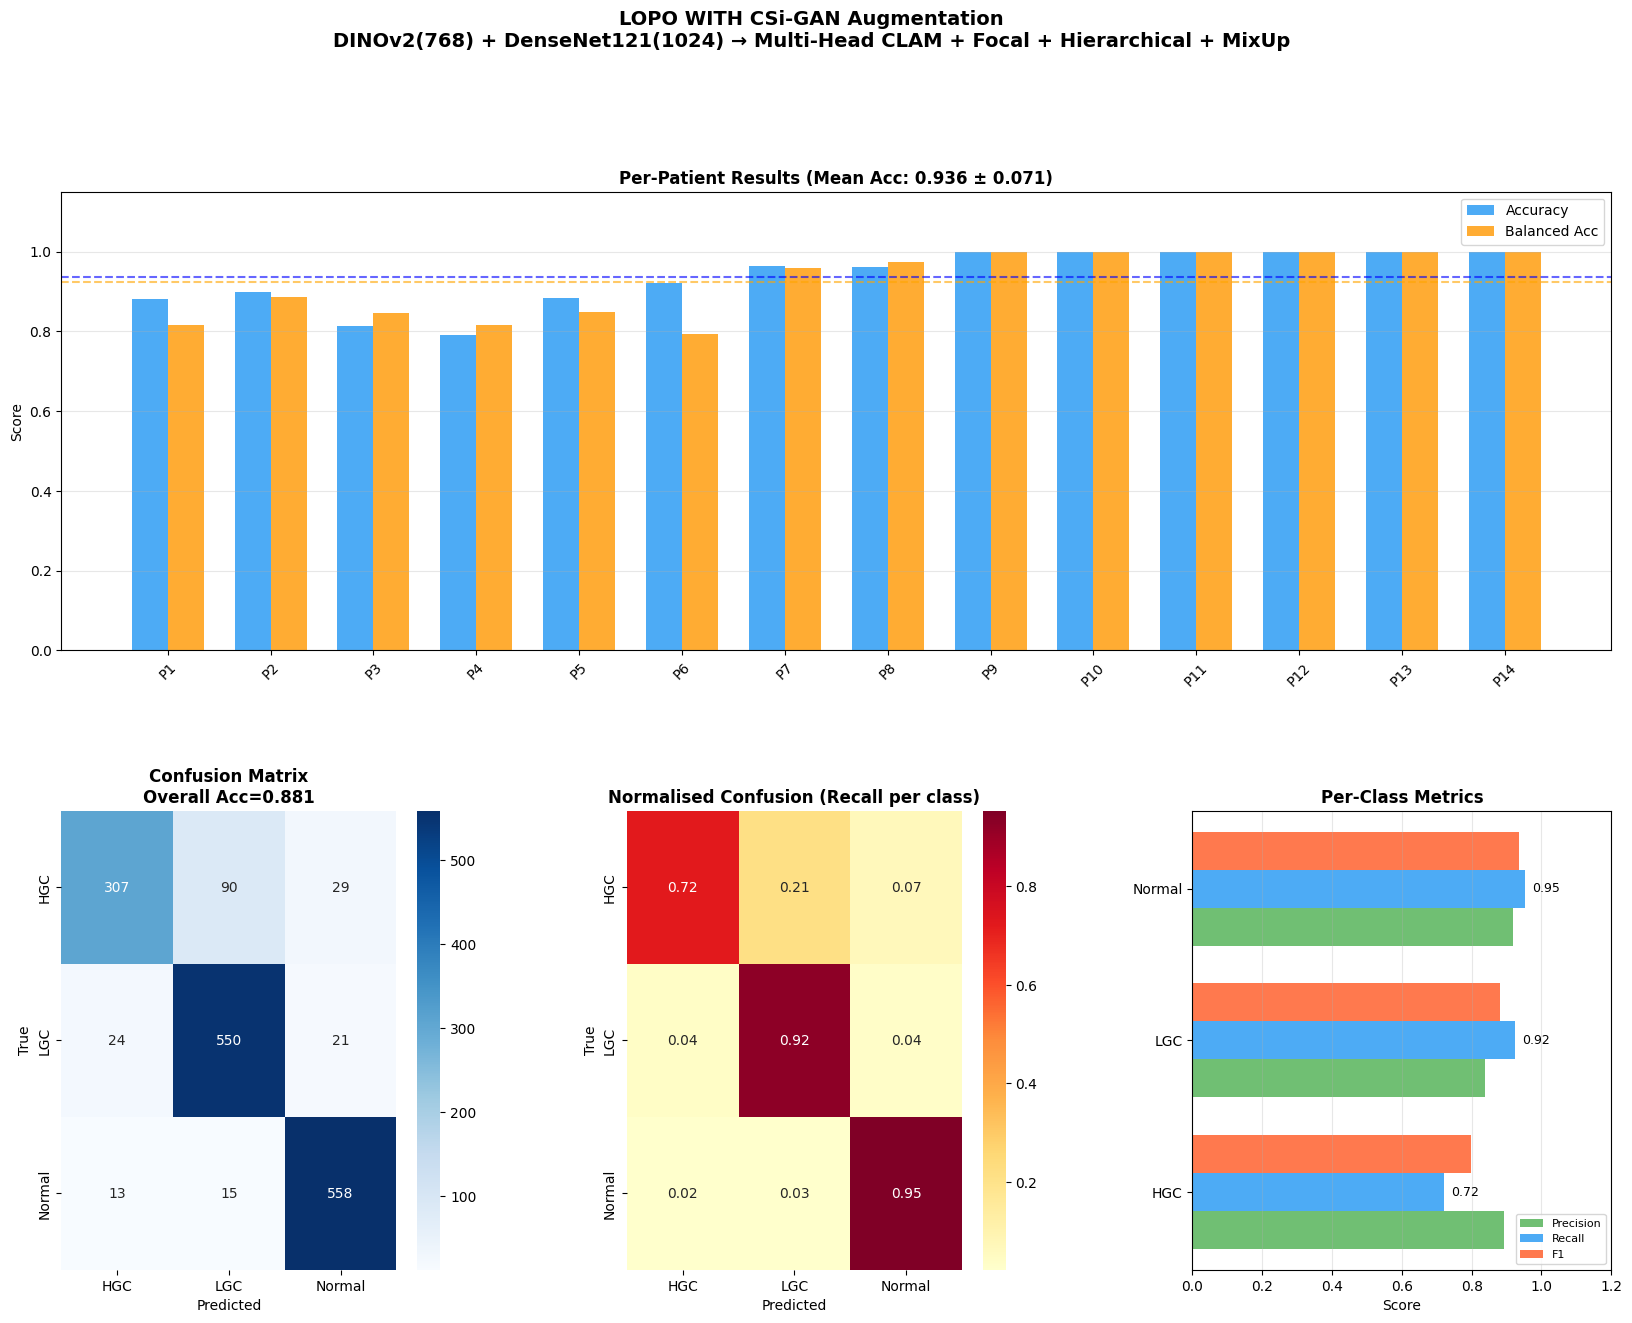

✓ Saved lopo_improved_results.png


In [17]:
# ============================================================
# CELL 17: VISUALIZATION
# ============================================================

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)

# ── Per-patient accuracy bar chart ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])
pids = [f"P{f['patient']}" for f in results['folds']]
accs = [f['image_accuracy'] for f in results['folds']]
bals = [f['balanced_accuracy'] for f in results['folds']]

x = np.arange(len(pids))
w = 0.35
ax1.bar(x - w/2, accs, w, color='#2196F3', alpha=0.8, label='Accuracy')
ax1.bar(x + w/2, bals, w, color='#FF9800', alpha=0.8, label='Balanced Acc')
ax1.set_ylabel('Score')
ax1.set_title(
    f'Per-Patient Results '
    f'(Mean Acc: {results["mean_patient_accuracy"]:.3f} '
    f'± {results["std_patient_accuracy"]:.3f})',
    fontweight='bold'
)
ax1.set_xticks(x)
ax1.set_xticklabels(pids, rotation=45)
ax1.set_ylim(0, 1.15)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(results['mean_patient_accuracy'], color='blue',
            linestyle='--', linewidth=1.5, alpha=0.6)
ax1.axhline(results['mean_patient_balanced'], color='orange',
            linestyle='--', linewidth=1.5, alpha=0.6)
ax1.legend()

# ── Confusion matrix ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
cm  = np.array(results['overall_confusion'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title(
    f'Confusion Matrix\nOverall Acc={results["overall_image_accuracy"]:.3f}',
    fontweight='bold'
)

# ── Normalised confusion matrix ──────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CFG.class_names, yticklabels=CFG.class_names, ax=ax3)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
ax3.set_title('Normalised Confusion (Recall per class)', fontweight='bold')

# ── Per-class metrics bar chart ──────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
recalls    = []
precisions = []
f1s        = []
for i in range(CFG.num_classes):
    row_sum = cm[i].sum()
    col_sum = cm[:, i].sum()
    recalls.append(cm[i, i] / max(row_sum, 1))
    precisions.append(cm[i, i] / max(col_sum, 1))
    p = cm[i, i] / max(col_sum, 1)
    r = cm[i, i] / max(row_sum, 1)
    f1s.append(2 * p * r / max(p + r, 1e-8))

y_pos = np.arange(CFG.num_classes)
bw    = 0.25
ax4.barh(y_pos - bw, precisions, bw, color='#4CAF50', alpha=0.8, label='Precision')
ax4.barh(y_pos,      recalls,    bw, color='#2196F3', alpha=0.8, label='Recall')
ax4.barh(y_pos + bw, f1s,        bw, color='#FF5722', alpha=0.8, label='F1')
for i in range(CFG.num_classes):
    ax4.text(recalls[i] + 0.02, i, f'{recalls[i]:.2f}', va='center', fontsize=9)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(CFG.class_names)
ax4.set_xlabel('Score')
ax4.set_title('Per-Class Metrics', fontweight='bold')
ax4.set_xlim(0, 1.2)
ax4.grid(axis='x', alpha=0.3)
ax4.legend(fontsize=8)

fig.suptitle(
    f'LOPO WITH CSi-GAN Augmentation\n'
    f'{backbone_desc} → Multi-Head CLAM + Focal + Hierarchical + MixUp',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('lopo_improved_results_v6.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved lopo_improved_results.png")